## Create the data table with document frequency

Before running this notebook, download this [data zip file](https://drive.google.com/file/d/1mAsDdocRAcfqYIYQb6-0BBmCdE-10vb4/view?usp=sharing) and store it under `bordIRlines/figures`

In [3]:
import os
import json
import pandas as pd
import numpy as np
import re

# Define the folder path where the JSON files are stored
folder_path = "RAG_data/gencitations/commandr"

# Define file names and corresponding ir_modes
files = {
    "gencitation_ablate_swap_vanilla_commandr_10.json": "ablate_swap",
    "gencitation_en_vanilla_commandr_10.json": "en",
    "gencitation_qlang_en_vanilla_commandr_10.json": "qlang_en",
    "gencitation_qlang_vanilla_commandr_10.json": "qlang",
    "gencitation_rel_langs_vanilla_commandr_10.json": "rel_langs"
}

# Initialize an empty list to store the data
data = []

# Iterate over each file and extract relevant data
for file_name, ir_mode in files.items():
    file_path = os.path.join(folder_path, file_name)  # Construct full path
    with open(file_path, "r", encoding="utf-8") as f:
        content = json.load(f)
        for query_id, details in content.items():
            raw_response = details.get("raw_response", "")

            # Extract explanation section (everything after "Explanation:")
            explanation_match = re.search(r"Explanation:\s*(.*)", raw_response, re.DOTALL)
            explanation = explanation_match.group(1) if explanation_match else ""

            # Extract all document numbers appearing inside <docX> or <docX,Y>
            doc_matches = re.findall(r"<doc(\d+(?:,\d+)*)>", explanation)
            
            # Flatten the list while preserving repeats
            art_list = [int(num) for match in doc_matches for num in match.split(",")]

            data.append({
                "query_id": query_id,
                "raw_response": raw_response,
                "explanation": explanation.strip(),  # Keep clean explanation text
                "doc_ids": details.get("doc_ids", []),  # Keep as a list
                "ir_mode": ir_mode,
                "art_list": art_list  # Store as a list of integer indices
            })

# Create a DataFrame
df = pd.DataFrame(data)

# Explode art_list so that each doc reference gets its own row
df_exploded = df.explode("art_list").reset_index(drop=True)

# Convert art_list to integer type (if NaN, replace with -1)
df_exploded["art_list"] = df_exploded["art_list"].fillna(-1).astype(int)

# Map art_list indices to corresponding doc_ids
df_exploded["mapped_doc_id"] = df_exploded.apply(
    lambda row: row["doc_ids"][row["art_list"]] if 0 <= row["art_list"] < len(row["doc_ids"]) else None, axis=1
)

# Drop rows where mapping failed (edge cases)
df_exploded = df_exploded.dropna(subset=["mapped_doc_id"])

# Count occurrences of each doc_id within each query
doc_freq_counts = df_exploded.groupby(["query_id", "mapped_doc_id"]).size().reset_index(name="doc_freq")

# Merge doc_freq back into df_exploded
df_final = df_exploded.merge(doc_freq_counts, on=["query_id", "mapped_doc_id"], how="left")

# Save to CSV
df_final.to_csv("RAG_data/gencitations/commandr/output/gencitation_commandr_flattened.csv", index=False, encoding="utf-8")

df_final.head(10)

/tmp/ipykernel_6527/519453112.py:56: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_exploded["art_list"] = df_exploded["art_list"].fillna(-1).astype(int)


,query_id,raw_response,explanation,doc_ids,ir_mode,art_list,mapped_doc_id,doc_freq
0,Abyei_en,"Cited Documents: 0,1,2,3,4,5,6,7,9\nChosen Opt...","because Abyei is a region in Sudan, located in...","[947434_p0, 3711_p0, 947434_p2, 342661_p1, 371...",ablate_swap,0,947434_p0,1
1,Abyei_en,"Cited Documents: 0,1,2,3,4,5,6,7,9\nChosen Opt...","because Abyei is a region in Sudan, located in...","[947434_p0, 3711_p0, 947434_p2, 342661_p1, 371...",ablate_swap,2,947434_p2,1
2,Abyei_en,"Cited Documents: 0,1,2,3,4,5,6,7,9\nChosen Opt...","because Abyei is a region in Sudan, located in...","[947434_p0, 3711_p0, 947434_p2, 342661_p1, 371...",ablate_swap,5,3711_p108,1
3,Heglig_en,"Cited Documents: 1,2,3,4,5,7,9\nChosen Option:...","because Heglig is a city in Sudan <doc1>, loca...","[1275055_p1, 1275055_p0, 1275055_p2, 1275055_p...",ablate_swap,1,1275055_p0,3
4,Heglig_en,"Cited Documents: 1,2,3,4,5,7,9\nChosen Option:...","because Heglig is a city in Sudan <doc1>, loca...","[1275055_p1, 1275055_p0, 1275055_p2, 1275055_p...",ablate_swap,1,1275055_p0,3
5,Heglig_en,"Cited Documents: 1,2,3,4,5,7,9\nChosen Option:...","because Heglig is a city in Sudan <doc1>, loca...","[1275055_p1, 1275055_p0, 1275055_p2, 1275055_p...",ablate_swap,1,1275055_p0,3
6,Heglig_en,"Cited Documents: 1,2,3,4,5,7,9\nChosen Option:...","because Heglig is a city in Sudan <doc1>, loca...","[1275055_p1, 1275055_p0, 1275055_p2, 1275055_p...",ablate_swap,3,1275055_p6,1
7,Heglig_en,"Cited Documents: 1,2,3,4,5,7,9\nChosen Option:...","because Heglig is a city in Sudan <doc1>, loca...","[1275055_p1, 1275055_p0, 1275055_p2, 1275055_p...",ablate_swap,2,1275055_p2,2
8,Heglig_en,"Cited Documents: 1,2,3,4,5,7,9\nChosen Option:...","because Heglig is a city in Sudan <doc1>, loca...","[1275055_p1, 1275055_p0, 1275055_p2, 1275055_p...",ablate_swap,2,1275055_p2,2
9,Heglig_en,"Cited Documents: 1,2,3,4,5,7,9\nChosen Option:...","because Heglig is a city in Sudan <doc1>, loca...","[1275055_p1, 1275055_p0, 1275055_p2, 1275055_p...",ablate_swap,5,1275055_p4,2


## Merge language classification and doc frequency

In [4]:
import json
import pandas as pd

# File paths
json_file_path = "RAG_data/all_docs.json"
csv_file_path = "RAG_data/gencitations/commandr/output/gencitation_commandr_flattened.csv"
output_csv_path = "RAG_data/gencitations/commandr/output/final_commandr_data.csv"

# Step 1: Load JSON and create a DataFrame (Document ID → Language Mapping)
with open(json_file_path, "r", encoding="utf-8") as file:
    all_docs = json.load(file)

# Extract document-language mapping
doc_language_mapping = []
for language, docs in all_docs.items():
    for doc_id in docs.keys():
        doc_language_mapping.append([doc_id, language])

# Convert to DataFrame
language_df = pd.DataFrame(doc_language_mapping, columns=["mapped_doc_id", "doc_lang"])
# print(language_df.head(10))

# Step 2: Load the expanded queries CSV file
queries_df = pd.read_csv(csv_file_path)

# Step 3: Merge DataFrames on Document_ID
merged_df = queries_df.merge(language_df, on="mapped_doc_id", how="left")
# print(merged_df.head(10)) 

# Step 4: Save the merged DataFrame back to CSV
merged_df.to_csv(output_csv_path, index=False)

## Analyze by language

/tmp/ipykernel_6527/3470078037.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pct = doc_ir_mode_counts.groupby('ir_mode').apply(


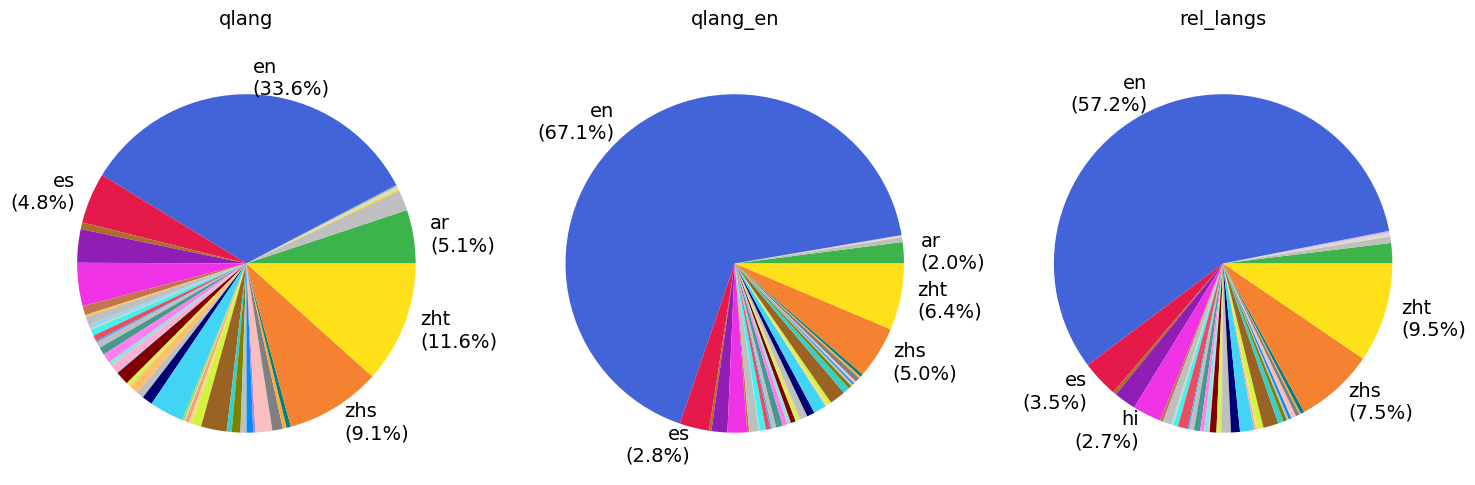

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data
df = pd.read_csv("RAG_data/gencitations/commandr/output/final_commandr_data.csv")

# Create document counts by ir_mode and language
doc_ir_mode_counts = df.groupby(['ir_mode', 'doc_lang']).size().reset_index(name='count')

# Calculate percentages within each ir_mode
df_pct = doc_ir_mode_counts.groupby('ir_mode').apply(
    lambda x: pd.Series(
        x['count'].values / x['count'].sum() * 100,
        index=x['doc_lang']
    )
).unstack()

# Filter for only the last three modes
selected_modes = ['qlang', 'qlang_en', 'rel_langs']

# Create a consistent color palette for all categories
pastel_colors = {
    'en': '#4363d8',    # blue
    'ar': '#3cb44b',    # green
    'zht': '#ffe119',   # yellow
    'zhs': '#f58231',   # orange
    'es': '#e6194b',    # red
    'fr': '#911eb4',    # purple
    'ru': '#42d4f4',    # cyan
    'hi': '#f032e6',    # magenta
    'ms': '#800000',    # maroon
    'sw': '#9a6324',    # brown
    'ko': '#469990',    # teal
    'pt': '#000075',    # navy
    'th': '#808000',    # olive
    'uk': '#fabebe',    # pink
    'ur': '#808080',    # gray
    'vi': '#008080',    # teal
    'fa': '#aa6e28',    # brown
    'sr': '#d2f53c',    # lime
    'iw': '#46f0f0',    # light blue
    'ja': '#e84d60',    # coral
    'hr': '#c47451',    # terra cotta
    'tl': '#008cf9',    # bright blue
    'ky': '#ff80ed',    # bright pink
    'bn': '#ffd700',    # gold
    'bs': '#d9d9d9',    # light gray
    'sn': '#d9f7be',    # light green
    'sq': '#ffd591',    # light orange
    'da': '#d3adf7',    # light purple
    'dz': '#ffe7ba',    # wheat
    'id': '#91d5ff',    # sky blue
    'is': '#ffa39e',    # salmon
    'it': '#b7eb8f',    # lime green
    'lo': '#87e8de',    # turquoise
    'mg': '#ffadd2',    # pink
    'mn': '#adc6ff',    # periwinkle
    'my': '#d3f261',    # yellow green
    'ne': '#ffc069',    # peach
    'sl': '#95de64',    # grass green
    'so': '#ff9c6e',    # coral orange
    'tg': '#36cfc9',    # aqua
    'to': '#ff85c0',    # hot pink
    'tr': '#b37feb',    # medium purple
    'uz': '#ffa940',    # tangerine
    'el': '#73d13d',    # lime green
    'ht': '#ffc53d',    # golden yellow
    'ka': '#40a9ff',    # bright blue
    'other': '#bfbfbf'  # medium gray
}

# Create the figure
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for idx, mode in enumerate(selected_modes):
    data = df_pct.loc[mode].dropna()
    
    # Sort values and identify top 5 categories
    top_5_indices = data.nlargest(5).index
    
    # Create labels - empty for non-top-5 categories
    labels = []
    for cat in data.index:
        if cat in top_5_indices:
            labels.append(f'{cat}\n({data[cat]:.1f}%)')
        else:
            labels.append('')
    
    # Create color list ensuring consistency
    colors = [pastel_colors.get(cat, pastel_colors['other']) for cat in data.index]
    
    axes[idx].pie(data.values, 
                 labels=labels,
                 colors=colors,
                 textprops={'fontsize': 14})
    axes[idx].set_title(mode, fontsize=14, pad=20)

plt.tight_layout()
plt.savefig("piecharts.png")
plt.show()

## Analyze Rellang mode

In [8]:
import pandas as pd

data = pd.read_csv("RAG_data/gencitations/commandr/output/final_commandr_data.csv")
data.columns
data = data[data["ir_mode"] == "rel_langs"]

# Extract query language from query_id
data['query_lang'] = data['query_id'].str.split('_').str[-1]

# Calculate total doc_freq for each query_lang
total_docs = data.groupby('query_lang')['doc_freq'].sum().reset_index()
total_docs.columns = ['query_lang', 'total_doc_freq']

# Calculate doc_freq where query_lang matches doc_lang
matching_docs = data[data['query_lang'] == data['doc_lang']].groupby('query_lang')['doc_freq'].sum().reset_index()
matching_docs.columns = ['query_lang', 'matching_doc_freq']

# Count documents by language for each query_lang and convert directly to percentages
lang_breakdown = data.groupby(['query_lang', 'doc_lang'])['doc_freq'].sum().reset_index()
lang_breakdown_pct = lang_breakdown.pivot(index='query_lang', columns='doc_lang', values='doc_freq')
row_sums = lang_breakdown_pct.sum(axis=1)
lang_breakdown_pct = (lang_breakdown_pct.div(row_sums, axis=0) * 100).round(2)

# Merge with the matching percentage calculation
result = pd.merge(total_docs, matching_docs, on='query_lang', how='left')
result['matching_percentage'] = (result['matching_doc_freq'] / result['total_doc_freq'] * 100).round(2)

# Merge with language breakdown percentages
result = pd.merge(result, lang_breakdown_pct.reset_index(), on='query_lang', how='left')

# Fill NaN values
result = result.fillna(0)

# Sort by total_doc_freq descending
result = result.sort_values('total_doc_freq', ascending=False)

# Reorder columns
base_cols = ['query_lang', 'total_doc_freq', 'matching_doc_freq', 'matching_percentage']
lang_cols = [col for col in result.columns if col not in base_cols]
result = result[base_cols + lang_cols]

# Save to CSV
result.to_csv("RAG_data/gencitations/commandr/output/rel_lang_analysis.csv", index=False)

# Display the results
print("\nDetailed Language Distribution Analysis (percentages only):")
print("--------------------------------------------------------")
print(result.to_string(index=False))


Detailed Language Distribution Analysis (percentages only):
--------------------------------------------------------
query_lang  total_doc_freq  matching_doc_freq  matching_percentage    ar    az    bn    bs    da     en    es    fa    fr    hi    hr    hy    id   is    it   iw    ja    ka    km    ko    ky     lo   mg    mn    ms    my   ne    nl    pt    ru   sl   sn    so    sq    sr    sw    tg    th    ti    tl   tr    uk    ur    uz    vi   zhs   zht
        en            8911             8450.0                94.83  0.00  0.07  0.00  0.02  0.04  94.83  0.70  0.00  0.77  0.06  0.00   0.0  0.00 0.00  0.01  0.0  0.26   0.0  0.00  0.01  0.01   0.00 0.01  0.00  0.08  0.00 0.00  0.66  0.12  0.43 0.00  0.0  0.00  0.00  0.00  0.46  0.00  0.00  0.00  0.03 0.00  0.04  0.00  0.00  0.02  0.63  0.73
       zht            3780             1698.0                44.92  0.00  0.00  0.00  0.00  0.00  34.76  0.00  0.00  0.00  1.11  0.00   0.0  0.00 0.00  0.00  0.0  0.13   0.0  0.00  0.05  0.00   

## Analyze other RAG modes

In [10]:
data = pd.read_csv("RAG_data/gencitations/commandr/output/final_commandr_data.csv")
data.columns


import pandas as pd

# Extract query language from query_id
data['query_lang'] = data['query_id'].str.split('_').str[-1]

# Initialize empty list to store results
all_results = []

# Process each IR mode
for mode in data['ir_mode'].unique():
    # Filter data for current mode
    mode_data = data[data['ir_mode'] == mode]
    
    # Calculate total doc_freq for each query_lang
    total_docs = mode_data.groupby('query_lang')['doc_freq'].sum().reset_index()
    total_docs.columns = ['query_lang', 'total_doc_freq']
    
    # Calculate doc_freq where query_lang matches doc_lang
    matching_docs = mode_data[mode_data['query_lang'] == mode_data['doc_lang']].groupby('query_lang')['doc_freq'].sum().reset_index()
    matching_docs.columns = ['query_lang', 'matching_doc_freq']
    
    # Merge and calculate percentage
    result = pd.merge(total_docs, matching_docs, on='query_lang', how='left')
    result['matching_percentage'] = (result['matching_doc_freq'] / result['total_doc_freq'] * 100).round(2)
    
    # Fill NaN values
    result = result.fillna(0)
    
    # Add IR mode column
    result['ir_mode'] = mode
    
    # Sort by total_doc_freq descending
    result = result.sort_values('total_doc_freq', ascending=False)
    
    # Append to results list
    all_results.append(result)

# Combine all results
final_result = pd.concat(all_results, ignore_index=True)

# Save to CSV
final_result.to_csv("RAG_data/gencitations/commandr/output/ir_mode_analysis.csv", index=False)

# Display the results grouped by IR mode
print("\nIR Mode Analysis - Matching Percentages:")
print("----------------------------------------")
for mode in final_result['ir_mode'].unique():
    print(f"\nIR Mode: {mode}")
    print(final_result[final_result['ir_mode'] == mode].drop('ir_mode', axis=1).to_string(index=False))
    print("\n" + "-"*50)


IR Mode Analysis - Matching Percentages:
----------------------------------------

IR Mode: ablate_swap
query_lang  total_doc_freq  matching_doc_freq  matching_percentage
       zht            1794                0.0                  0.0
       zhs            1229                0.0                  0.0
        es             716                0.0                  0.0
        fr             605                0.0                  0.0
        en             557                0.0                  0.0
        hi             398                0.0                  0.0
        ar             353                0.0                  0.0
        sw             308                0.0                  0.0
        iw             304                0.0                  0.0
        ru             293                0.0                  0.0
        uk             232                0.0                  0.0
        hy             213                0.0                  0.0
        ms             1

In [11]:
ir_data = pd.read_csv("RAG_data/gencitations/commandr/document_counts.csv")
ir_data.columns
# specific_languages = ['en', 'zhs', 'zht','hi', 'ko']

Index(['query_lang', 'native', 'foreign', 'total', 'ir_match'], dtype='object')

## High vs. Low Resource

19
25


findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times New Roman' not found.
findfont: Font family 'Times Ne

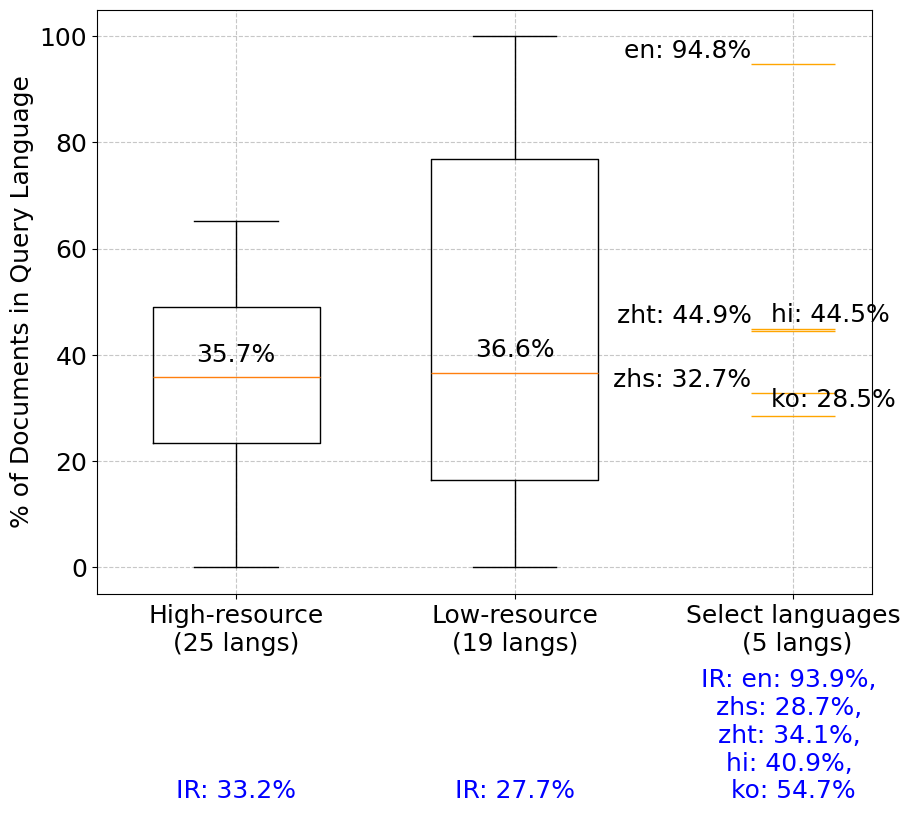

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Your existing language lists remain the same
# high_resource_languages = ['en', 'zht', 'ar', 'zhs', 'es', 'fr', 'ru', 'hi', 'ms', 'sw', 'ko',
#                           'pt', 'iw', 'ja', 'hr', 'tl', 'vi', 'fa', 'nl', 'uz', 'da', 'id',
#                           'is', 'tr', 'sl', 'bn', 'bs', 'el', 'it', 'sq']
# low_resource_languages = ['az', 'hy', 'th', 'uk', 'ur', 'sr', 'ky', 'tg', 'mg', 'ne', 'my', 'dz',
#                          'lo', 'so', 'mn', 'ht', 'to', 'ka', 'sn', 'km', 'ti']

low_resource_languages = ['az', 'hy', 'th', 'uk', 'ur', 'sr', 'ky', 'tg', 'mg', 'ne', 'my', 'lo', 'so', 'mn', 'ht', 'ka', 'sn', 'km', 'ti']
high_resource_languages = ['ar', 'es', 'fr', 'ru', 'ms', 'sw', 'pt', 'iw', 'ja', 'hr', 'tl', 'vi', 'fa', 'nl', 'uz', 'da', 'id', 'is', 'tr', 'sl', 'bn', 'bs', 'el', 'it', 'sq']
select_languages = ['en', 'zhs', 'zht', 'hi', 'ko']
print(len(low_resource_languages))
print(len(high_resource_languages))
# Keep your existing data reading and processing code
data = pd.read_csv("RAG_data/gencitations/commandr/output/final_commandr_data.csv")
ir_data = pd.read_csv("RAG_data/gencitations/commandr/document_counts.csv")
data['query_lang'] = data['query_id'].str.split('_').str[-1]
rel_langs_data = data[data['ir_mode'] == 'rel_langs']

# Keep your existing calculate_metrics function
def calculate_metrics(languages, data_df, ir_df):
    percentages = []
    ir_matches = []
    for lang in languages:
        query_data = data_df[data_df['query_lang'] == lang]
        if len(query_data) > 0:
            matching_docs = query_data[query_data['query_lang'] == query_data['doc_lang']]['doc_freq'].sum()
            total_docs = query_data['doc_freq'].sum()
            if total_docs > 0:
                percentages.append((matching_docs / total_docs) * 100)
        
        ir_match_value = ir_df[ir_df['query_lang'] == lang]['ir_match'].median()
        if pd.notna(ir_match_value):
            ir_matches.append(ir_match_value)
    
    return percentages, np.median(ir_matches) if ir_matches else np.nan

# Calculate metrics for all groups
high_resource_percentages, hr_ir_median = calculate_metrics(high_resource_languages, rel_langs_data, ir_data)
low_resource_percentages, lr_ir_median = calculate_metrics(low_resource_languages, rel_langs_data, ir_data)
select_lang_data = []
select_lang_ir = []
for lang in select_languages:
    percentages, ir_median = calculate_metrics([lang], rel_langs_data, ir_data)
    if percentages:
        select_lang_data.append(percentages[0])
        select_lang_ir.append(ir_median)

# Create plot
plt.figure(figsize=(10, 8))
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 18

# Plot boxplots for high/low resource
boxes = plt.boxplot([high_resource_percentages, low_resource_percentages], 
                   positions=[1, 2],
                   widths=0.6)

# Add median labels for boxplots
plt.text(1, np.median(high_resource_percentages) + 3, f'{np.median(high_resource_percentages):.1f}%', 
         ha='center', va='baseline')
plt.text(2, np.median(low_resource_percentages) + 3, f'{np.median(low_resource_percentages):.1f}%', 
         ha='center', va='baseline')

# Plot select languages as horizontal lines
for i, (value, lang) in enumerate(zip(select_lang_data, select_languages)):
    # Plot horizontal line
    plt.hlines(y=value, xmin=2.85, xmax=3.15, color='orange', linewidth=1)
    # Add label above the line
    if lang == 'hi' or lang == 'ko':
            plt.text(2.92, value + 3, f'{lang}: {value:.1f}%', ha='left', va='center')
    else:
        plt.text(2.85, value + 3, f'{lang}: {value:.1f}%', ha='right', va='center_baseline')
# 'top', 'bottom', 'center', 'baseline', 'center_baseline'
# Customize plot
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylabel('% of Documents in Query Language')

# Set x-axis labels
plt.xticks([1, 2, 3], ['High-resource\n(25 langs)', 'Low-resource\n(19 langs)', 'Select languages\n (5 langs)'])

# Add IR labels closer to x-axis labels
plt.text(1, -0.35, f'IR: {hr_ir_median*100:.1f}%', ha='center', transform=plt.gca().get_xaxis_transform(), color = 'blue')
plt.text(2, -0.35, f'IR: {lr_ir_median*100:.1f}%', ha='center', transform=plt.gca().get_xaxis_transform(), color = 'blue')
ir_text = 'IR: ' + ', \n'.join([f'{lang}: {ir*100:.1f}%' for lang, ir in zip(select_languages, select_lang_ir)])
plt.text(3, -0.35, ir_text, ha='center', transform=plt.gca().get_xaxis_transform(), color = 'blue')

# Adjust bottom margin (smaller than before)
plt.subplots_adjust(bottom=0.15)

plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()